# DLSD express route comparison plots

Hourly **DLSD segment duration** (`dlsd_minutes`) for rush routes **134–136, 143, 148** paired with all-day **146 / 147** at the same northern DLSD exit. Compare **13x (Wacker)** vs **14x (Michigan & Delaware)** downtown entries.

**This notebook:** DLSD **minutes only** (median, IQR, p95). Implied speed charts are omitted to keep overlays readable.

**Colors:** routes **134–136** blue; **143–148** purple (`cta_analysis.mplstyle` palette).

## Comparison panes (chart titles)

| Pane | Title | Routes |
|------|-------|--------|
| A | **Fullerton** | 134 vs 143 |
| B | **Belmont** | 135 vs 146 |
| C | **Irving Park** | 136 vs 148 |
| D | **Foster** (solo) | 147 |

Segment endpoints in data still use CTA stop names (e.g. Fullerton pane: DLSD hop ends at **Stockton & Arlington**). Titles name the arterial where buses leave DLSD.

## Day slices

| Slice | Calendar | Routes in view |
|-------|----------|----------------|
| `mon_fri` | Mon–Fri | rush + 146/147 (first plot block below) |
| `weekday` | Mon–Thu | rush + 146/147 |
| `friday` | Friday | rush + 146/147 |
| `weekend` | Sat–Sun | **146 and 147 only** (rush does not run) |

**Mon–Fri block** (first plot section below): pooled Mon–Fri stats; rush hours still gated by Mon–Thu `valid_rush_plot_cells()` targets.

Rush series: only **`valid_rush_plot_cells()`** targets (weekday Mon–Thu `n_runs ≥ 30`); Friday and Mon–Fri panes reuse that set. See [`dlsd_rush_sample_counts.ipynb`](dlsd_rush_sample_counts.ipynb).

## Vault references

- `2026-09-24-dlsd-rush-express-routes.md` — panes, plot spec
- `2026-09-24-dlsd-rush-hour-min-sample.md` — gating rules
- `2026-09-23-lsd-express-segment-boundaries.md` — `dlsd_minutes`, `analysis_ok`
- `2026-09-24-dlsd-cache-last30d-semantics.md` — local cache window

Data: local `data/mansueto/trips_{pid}_last365d.parquet` via `cache_dlsd_parquets.py --days 365`. Window is **N days ending at parquet max `bus_stop_time`**, not calendar “last N days from today”.


In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

_nb = Path.cwd() if (Path.cwd() / "cta_analysis.mplstyle").is_file() else Path.cwd() / "notebooks"

from cta_bus.dlsd_run_quality import (
    DEFAULT_PLOT_HOURS,
    RUSH_ROUTES,
    build_dlsd_runs,
    day_slice_mask,
    hour_dlsd_stats,
    hour_run_counts,
    load_dlsd_boundaries,
    routes_for_day_slice,
    valid_rush_plot_cells,
)

REPO_ROOT = _nb.parent if _nb.name == "notebooks" else _nb
_style = REPO_ROOT / "notebooks" / "cta_analysis.mplstyle"
if _style.is_file():
    plt.style.use(_style)

PLOT_HOURS = DEFAULT_PLOT_HOURS
DIRECTIONS = ["Northbound", "Southbound"]
DAY_SLICES = ["weekday", "friday", "weekend"]
DAY_SLICE_LABELS = {
    "weekday": "weekday (Mon–Thu)",
    "friday": "Friday",
    "weekend": "weekend (Sat–Sun)",
    "mon_fri": "Mon–Fri",
}
DLSD_MINUTES_YMAX = 70  # None to let matplotlib auto-scale

COMPARISON_PANES = [
    {"id": "fullerton", "title": "Fullerton", "routes": ("134", "143")},
    {"id": "belmont", "title": "Belmont", "routes": ("135", "146")},
    {"id": "irving", "title": "Irving Park", "routes": ("136", "148")},
]
SOLO_147 = {"id": "foster", "title": "Foster", "routes": ("147",)}
ALL_PANES = list(COMPARISON_PANES) + [SOLO_147]

ROUTE_FAMILY_COLOR = {
    "13": "#4E79A7",  # 134–136
    "14": "#9D8AB8",  # 143–148
}


def color_for_route(route: str) -> str:
    return ROUTE_FAMILY_COLOR[str(route)[:2]]


In [2]:
boundaries = load_dlsd_boundaries()
dlsd_runs = build_dlsd_runs(
    boundaries, prefer_local=True, cache_variant="last365d"
)
dlsd_runs = dlsd_runs.loc[dlsd_runs["analysis_ok"]].copy()
dlsd_runs["route"] = dlsd_runs["route"].astype(str)
print(f"analysis_ok runs: {len(dlsd_runs):,}")
print(
    "entry_time range:",
    dlsd_runs["entry_time"].min(),
    "→",
    dlsd_runs["entry_time"].max(),
)
# valid_cells = valid_rush_plot_cells(dlsd_runs)
# print(f"Valid rush plot cells (weekday ≥30): {len(valid_cells)}")
# display(valid_cells.sort_values(["route", "rtdir", "hour"]).head(20))


analysis_ok runs: 176,949
entry_time range: 2025-07-27 09:24:13.473592920 → 2026-07-28 00:28:39.585857208
Valid rush plot cells (weekday ≥30): 43


,route,rtdir,hour,n_runs
0,134,Northbound,15,98
1,134,Northbound,16,1103
2,134,Northbound,17,1188
3,134,Northbound,18,719
4,134,Southbound,6,799
5,134,Southbound,7,2017
6,134,Southbound,8,1919
7,134,Southbound,9,544
8,135,Northbound,15,574
9,135,Northbound,16,1030


Require more runs

In [8]:
valid_cells = valid_rush_plot_cells(dlsd_runs, min_runs=365)
print(f"Valid rush plot cells (weekday ≥30): {len(valid_cells)}")
display(valid_cells.sort_values(["route", "rtdir", "hour"]).head(20))


Valid rush plot cells (weekday ≥30): 35


,route,rtdir,hour,n_runs
0,134,Northbound,16,1103
1,134,Northbound,17,1188
2,134,Northbound,18,719
3,134,Southbound,6,799
4,134,Southbound,7,2017
5,134,Southbound,8,1919
6,134,Southbound,9,544
7,135,Northbound,15,574
8,135,Northbound,16,1030
9,135,Northbound,17,1438


## Plot helpers


In [3]:
def route_stats(dlsd_runs, day_slice, route, rtdir, valid_cells):
    allowed = routes_for_day_slice(day_slice)
    if str(route) not in {str(r) for r in allowed}:
        return None
    sub = dlsd_runs.loc[
        day_slice_mask(dlsd_runs, day_slice)
        & (dlsd_runs["route"] == str(route))
        & (dlsd_runs["rtdir"] == rtdir)
    ]
    vc = valid_cells if str(route) in RUSH_ROUTES else None
    return hour_dlsd_stats(
        sub,
        PLOT_HOURS,
        route=str(route),
        rtdir=rtdir,
        valid_cells=vc,
    )


def _masked_xy(hours, values):
    y = np.asarray(values, dtype=float)
    x = np.asarray(hours, dtype=float)
    m = np.isfinite(y)
    return x[m], y[m]


def plottable_hours(stats):
    """Hours with n_runs > 0 and finite median (post valid_cells mask)."""
    if stats is None or stats.empty:
        return []
    ok = stats["n_runs"].fillna(0).gt(0) & stats["median_min"].notna()
    return stats.loc[ok, "hour"].astype(int).tolist()


def plot_hour_stats_overlay(ax, stats, *, label, color):
    if stats is None or stats.empty:
        return
    h = stats["hour"].astype(int)
    q25, q75 = stats["q25_min"], stats["q75_min"]
    med, q95 = stats["median_min"], stats["q95_min"]
    x_lo, y_lo = _masked_xy(h, q25)
    x_hi, y_hi = _masked_xy(h, q75)
    if len(x_lo):
        ax.fill_between(x_lo, y_lo, y_hi, alpha=0.2, color=color, label=f"{label} IQR")
    x_m, y_m = _masked_xy(h, med)
    if len(x_m):
        ax.plot(x_m, y_m, marker="o", linestyle="-", color=color, label=f"{label} median")
    x_p, y_p = _masked_xy(h, q95)
    if len(x_p):
        ax.plot(x_p, y_p, linestyle="--", color=color, alpha=0.85, label=f"{label} p95")


def pane_routes_for_slice(pane, day_slice):
    allowed = routes_for_day_slice(day_slice)
    return tuple(r for r in pane["routes"] if str(r) in {str(x) for x in allowed})


def plot_comparison_pane(dlsd_runs, pane, day_slice, valid_cells):
    routes = pane_routes_for_slice(pane, day_slice)
    slice_label = DAY_SLICE_LABELS[day_slice]
    # sharex=False: NB/SB may have different rush hour windows
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False)
    for col, rtdir in enumerate(DIRECTIONS):
        ax = axes[col]
        if not routes:
            ax.text(
                0.5,
                0.5,
                "No service in this slice",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_xticks(PLOT_HOURS)
            ax.set_xlim(PLOT_HOURS[0] - 0.5, PLOT_HOURS[-1] + 0.5)
        else:
            stats_by_route = [
                route_stats(dlsd_runs, day_slice, route, rtdir, valid_cells)
                for route in routes
            ]
            for route, stats in zip(routes, stats_by_route):
                plot_hour_stats_overlay(
                    ax,
                    stats,
                    label=f"Route {route}",
                    color=color_for_route(route),
                )
            ax.legend(fontsize=7, loc="best")
            hours = sorted(
                {h for stats in stats_by_route for h in plottable_hours(stats)}
            )
            if hours:
                h_min, h_max = min(hours), max(hours)
                ax.set_xlim(h_min - 0.5, h_max + 0.5)
                ax.set_xticks(list(range(h_min, h_max + 1)))
            else:
                ax.set_xticks(PLOT_HOURS)
                ax.set_xlim(PLOT_HOURS[0] - 0.5, PLOT_HOURS[-1] + 0.5)
        if DLSD_MINUTES_YMAX is not None:
            ymin, ymax = ax.get_ylim()
            if ymax > DLSD_MINUTES_YMAX:
                ax.set_ylim(ymin, DLSD_MINUTES_YMAX)
        ax.set_title(rtdir)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Hour of day (entry at DLSD)")
        if col == 0:
            ax.set_ylabel("DLSD minutes")
    fig.suptitle(f"{pane['title']} — {slice_label}", y=1.02)
    fig.tight_layout()
    plt.show()


## Mon–Fri (all panes)


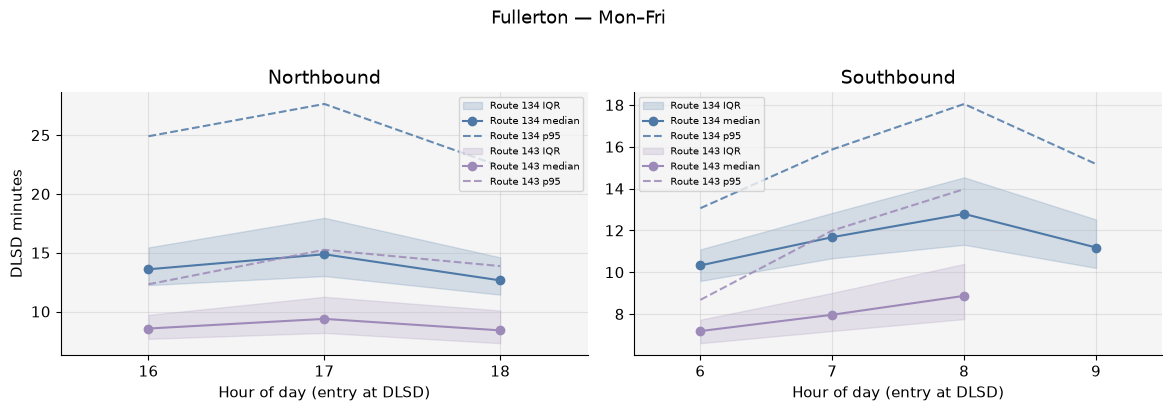

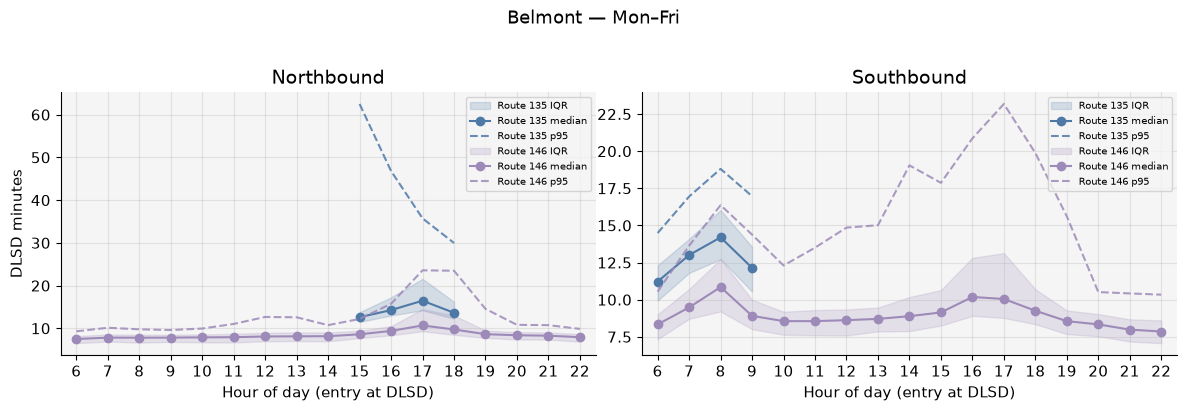

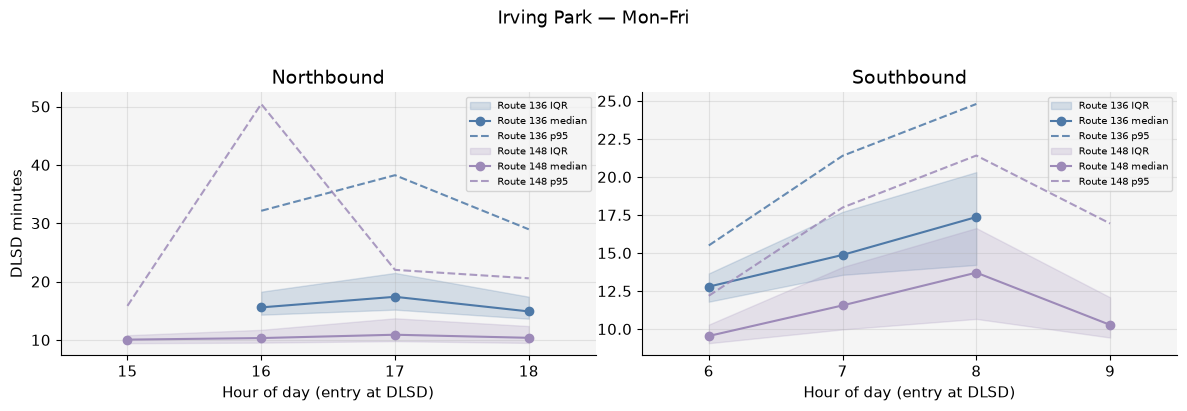

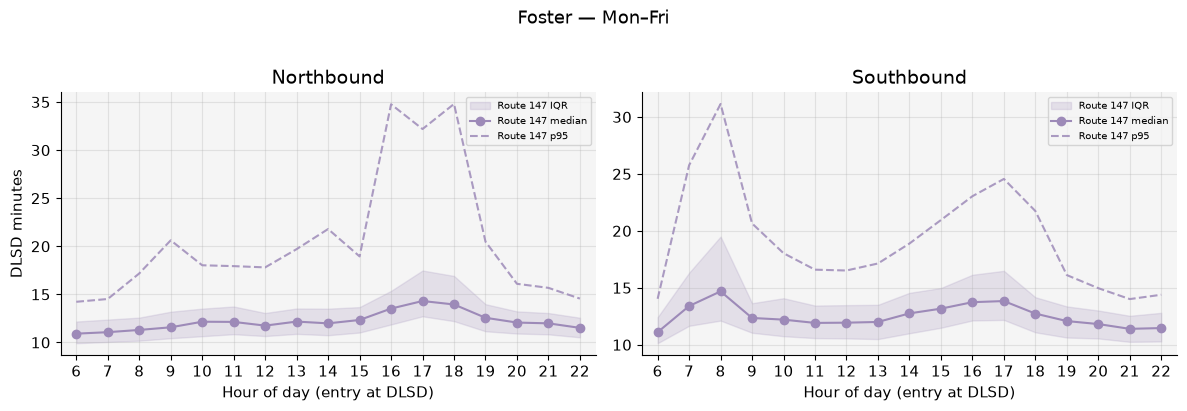

In [9]:
for pane in ALL_PANES:
    plot_comparison_pane(dlsd_runs, pane, "mon_fri", valid_cells)


## All panes × day slices


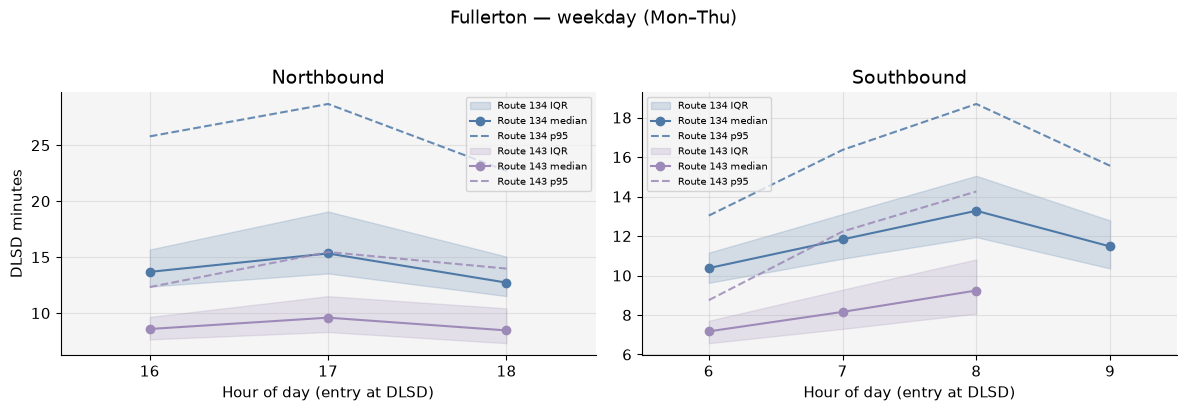

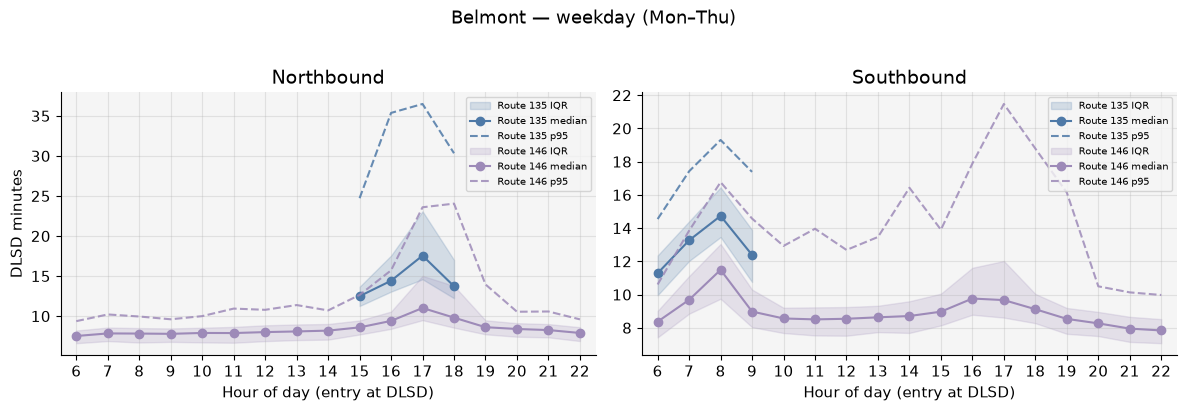

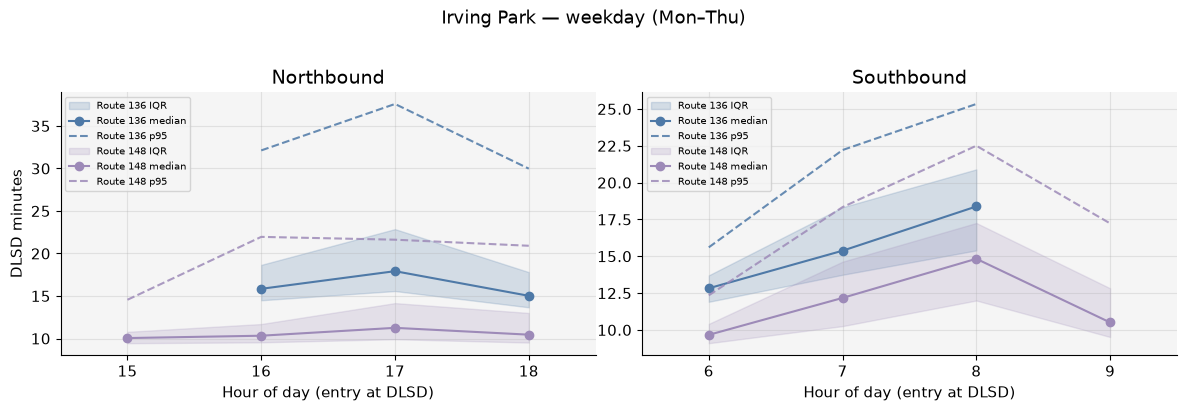

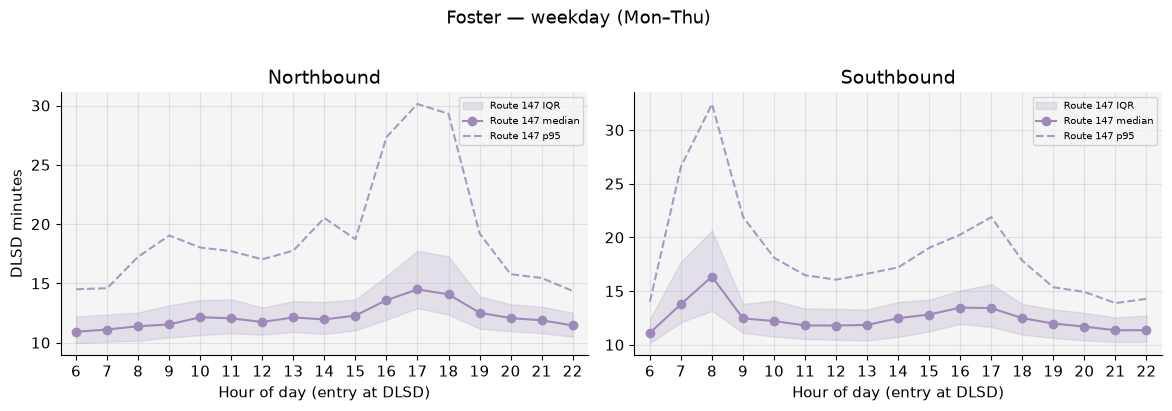

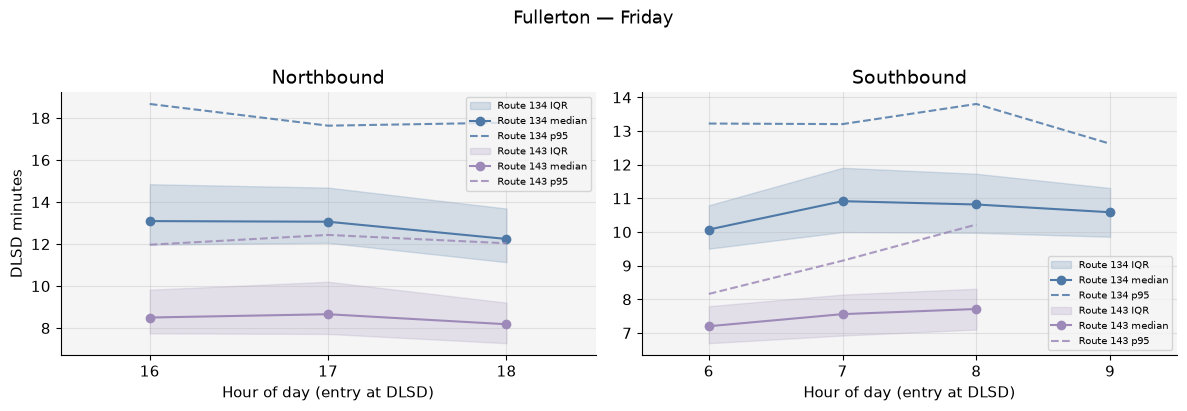

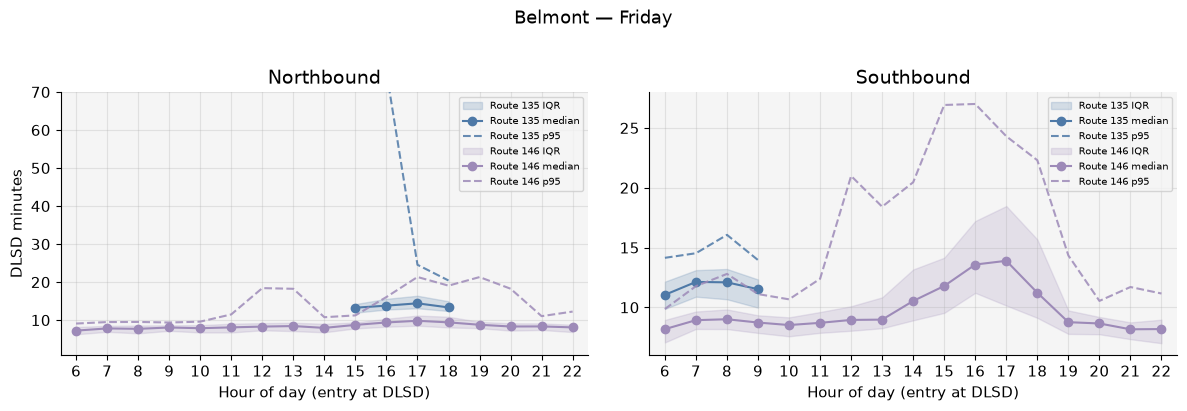

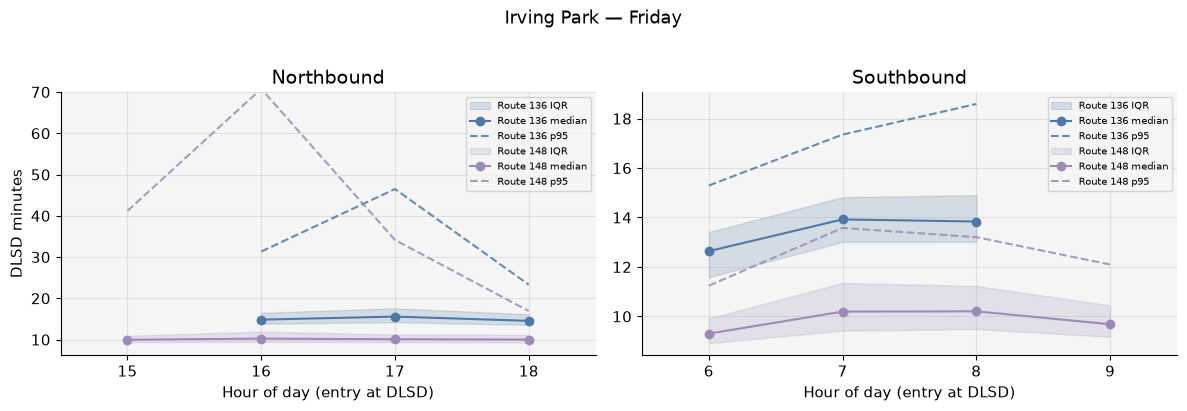

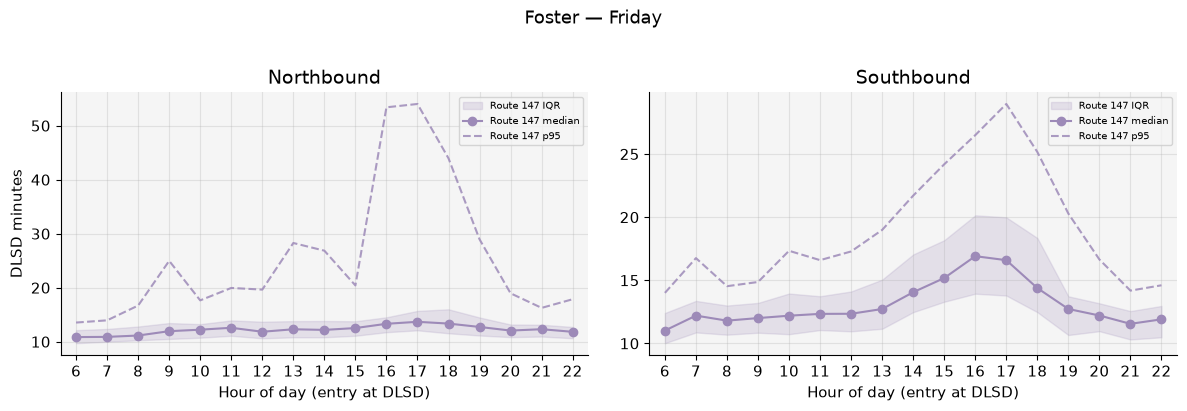

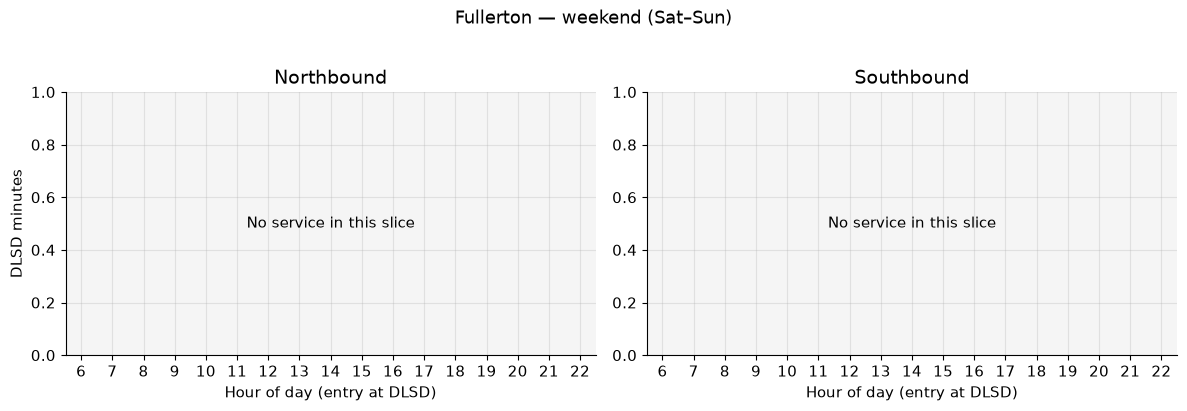

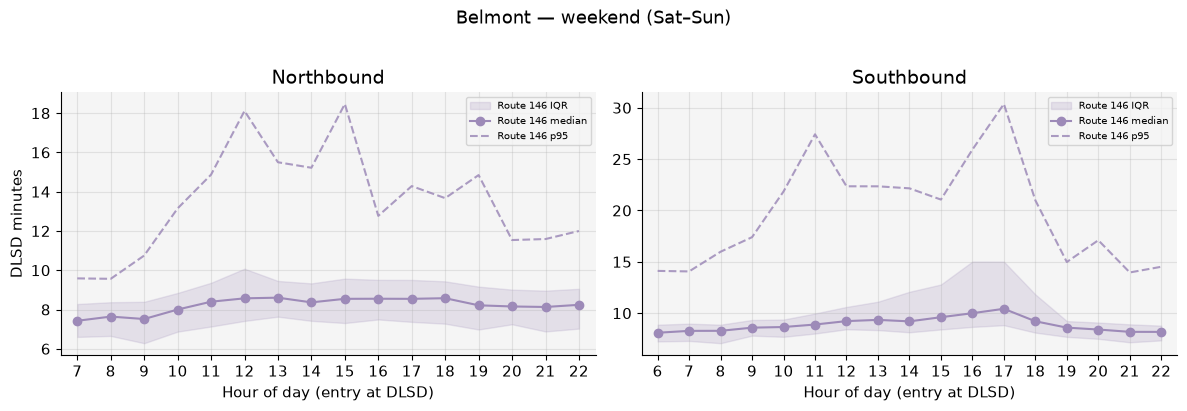

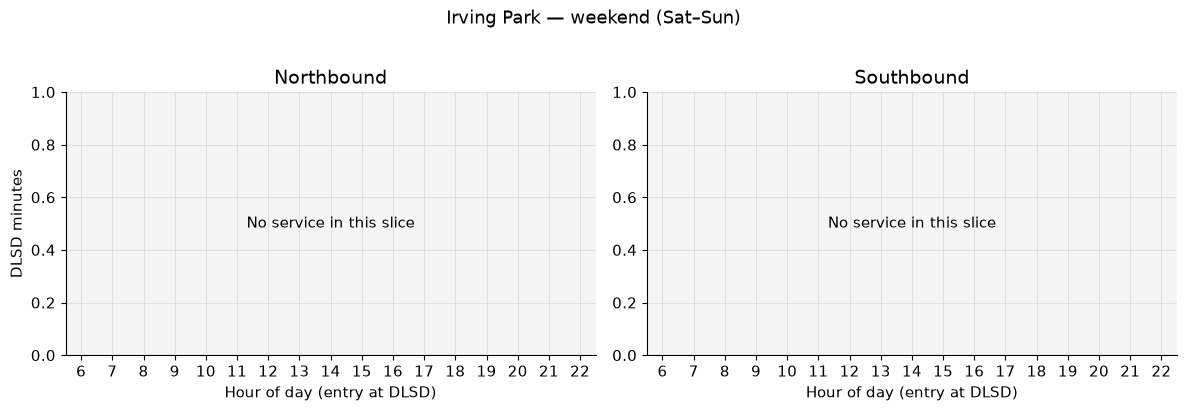

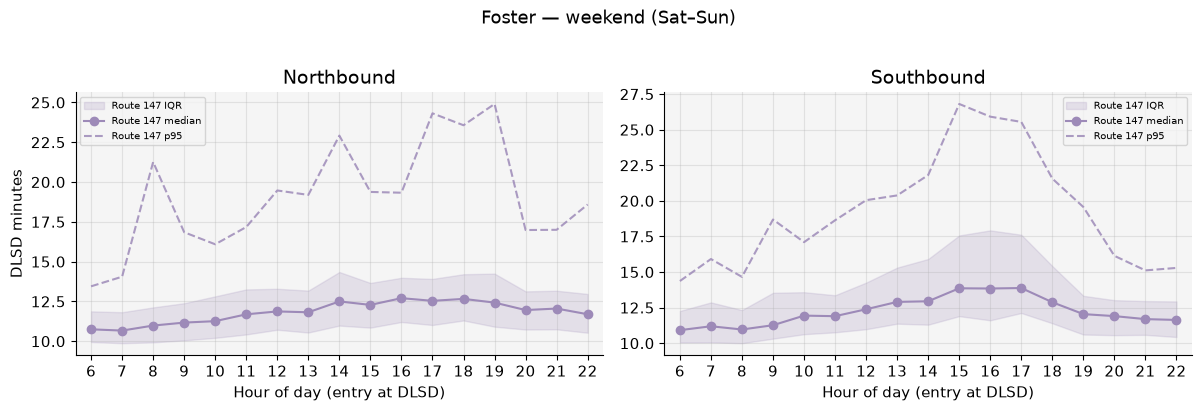

In [10]:
for day_slice in DAY_SLICES:
    for pane in ALL_PANES:
        plot_comparison_pane(dlsd_runs, pane, day_slice, valid_cells)


## Weekend sample counts (sanity)


In [11]:
weekend_counts = hour_run_counts(
    dlsd_runs, routes={"146", "147"}, day_slice="weekend"
)
print("Weekend analysis_ok runs (146/147) by hour:")
display(
    weekend_counts.sort_values(["route", "rtdir", "hour"]).head(30)
    if not weekend_counts.empty
    else "No weekend rows in cache window"
)


Weekend analysis_ok runs (146/147) by hour:


,route,rtdir,hour,n_runs,day_slice
0,146,Northbound,0,311,weekend
1,146,Northbound,1,43,weekend
2,146,Northbound,2,11,weekend
3,146,Northbound,3,6,weekend
4,146,Northbound,4,3,weekend
5,146,Northbound,5,2,weekend
6,146,Northbound,7,235,weekend
7,146,Northbound,8,267,weekend
8,146,Northbound,9,305,weekend
9,146,Northbound,10,291,weekend
